In [1]:
import requests
import pandas as pd
import time

API_KEY = "c96ddcf8e9d62c9de8732d7f42e97098"
BASE_URL = "https://api.themoviedb.org/3"

In [3]:
import pandas as pd
df_clean = pd.read_csv("movies_dataset.csv")  # load dataset yang sudah jadi
df_clean.shape

(1589, 10)

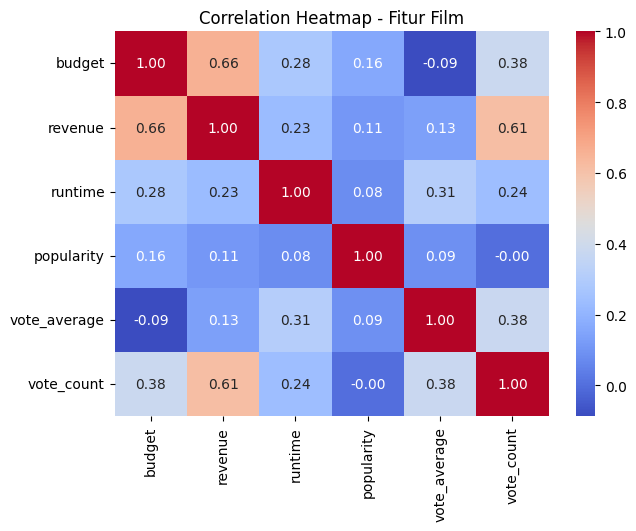

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

fitur = ["budget", "revenue", "runtime", "popularity", "vote_average", "vote_count"]
corr = df_clean[fitur].corr()

plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap - Fitur Film")
plt.show()

In [5]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

X = df_clean[["budget"]]
y = df_clean["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
model_simple = LinearRegression().fit(X_train, y_train)
pred = model_simple.predict(X_test)

print("Koefisien:", model_simple.coef_[0])
print("Intercept:", model_simple.intercept_)
print("R²:", r2_score(y_test, pred))
print("MAE:", mean_absolute_error(y_test, pred))

Koefisien: 3.0847555003911613
Intercept: 42664817.553269
R²: 0.4273785376426611
MAE: 131398235.21703161


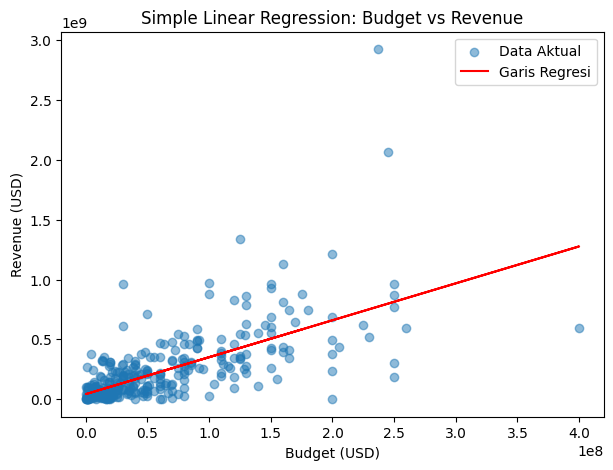

In [6]:
plt.figure(figsize=(7,5))
plt.scatter(X_test, y_test, alpha=0.5, label="Data Aktual")
plt.plot(X_test, pred, color="red", label="Garis Regresi")
plt.xlabel("Budget (USD)")
plt.ylabel("Revenue (USD)")
plt.title("Simple Linear Regression: Budget vs Revenue")
plt.legend()
plt.show()

In [7]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.stats.diagnostic import het_breuschpagan
from scipy import stats

fitur_X = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
X_multi = df_clean[fitur_X]
y_multi = df_clean["revenue"]

X_const = sm.add_constant(X_multi)
model_multi = sm.OLS(y_multi, X_const).fit()
print(model_multi.summary())

# 1. Uji Multikolinearitas (VIF)
vif_data = pd.DataFrame()
vif_data["Fitur"] = X_const.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i) for i in range(X_const.shape[1])]
print(vif_data)

# 2. Uji Heteroskedastisitas (Breusch-Pagan)
bp_test = het_breuschpagan(model_multi.resid, X_const)
print("Breusch-Pagan p-value:", bp_test[1])

# 3. Uji Normalitas Residual (Shapiro-Wilk)
shapiro_test = stats.shapiro(model_multi.resid)
print("Shapiro-Wilk p-value:", shapiro_test.pvalue)

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.591
Model:                            OLS   Adj. R-squared:                  0.590
Method:                 Least Squares   F-statistic:                     457.7
Date:                Fri, 24 Jul 2026   Prob (F-statistic):          3.02e-304
Time:                        19:30:09   Log-Likelihood:                -32591.
No. Observations:                1589   AIC:                         6.519e+04
Df Residuals:                    1583   BIC:                         6.523e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const        -9.211e+07   5.32e+07     -1.732   

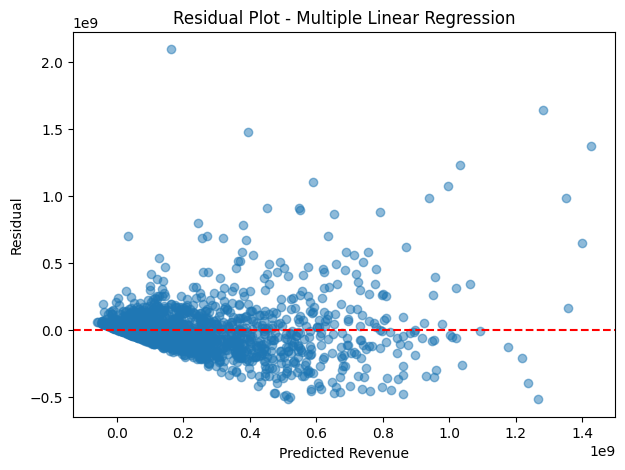

In [8]:
plt.figure(figsize=(7,5))
plt.scatter(model_multi.fittedvalues, model_multi.resid, alpha=0.5)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Revenue")
plt.ylabel("Residual")
plt.title("Residual Plot - Multiple Linear Regression")
plt.show()

R² Simple Linear Regression   : 0.4274
R² Multiple Linear Regression : 0.5954
MAE  (Multiple)               : 113,804,543
RMSE (Multiple)                : 192,010,872

Urutan variabel paling berpengaruh terhadap revenue:
       variabel  koefisien_standar
0        budget       1.543677e+08
4    vote_count       1.276496e+08
2    popularity       8.770344e+06
3  vote_average       7.666680e+06
1       runtime      -6.759760e+06


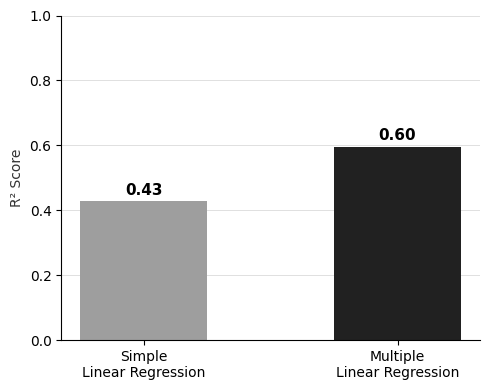

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

df = pd.read_csv("movies_dataset.csv")

# ---------- Simple Linear Regression (budget -> revenue) ----------
X_simple = df[["budget"]]
y = df["revenue"]

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)
model_simple = LinearRegression().fit(X_train, y_train)
pred_simple = model_simple.predict(X_test)
r2_simple = r2_score(y_test, pred_simple)

# ---------- Multiple Linear Regression (5 variabel) ----------
fitur_x = ["budget", "runtime", "popularity", "vote_average", "vote_count"]
X_multi = df[fitur_x]

X_train2, X_test2, y_train2, y_test2 = train_test_split(X_multi, y, test_size=0.2, random_state=42)
model_multi = LinearRegression().fit(X_train2, y_train2)
pred_multi = model_multi.predict(X_test2)
r2_multi = r2_score(y_test2, pred_multi)
mae_multi = mean_absolute_error(y_test2, pred_multi)
rmse_multi = np.sqrt(mean_squared_error(y_test2, pred_multi))

print(f"R² Simple Linear Regression   : {r2_simple:.4f}")
print(f"R² Multiple Linear Regression : {r2_multi:.4f}")
print(f"MAE  (Multiple)               : {mae_multi:,.0f}")
print(f"RMSE (Multiple)                : {rmse_multi:,.0f}")

# ---------- Variabel paling berpengaruh (lihat koefisien terstandarisasi) ----------
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_multi)
model_scaled = LinearRegression().fit(X_scaled, y)
koef_df = pd.DataFrame({
    "variabel": fitur_x,
    "koefisien_standar": model_scaled.coef_
}).sort_values("koefisien_standar", key=abs, ascending=False)
print("\nUrutan variabel paling berpengaruh terhadap revenue:")
print(koef_df)

# ---------- Chart: Perbandingan R² ----------
fig, ax = plt.subplots(figsize=(5, 4))
labels = ["Simple\nLinear Regression", "Multiple\nLinear Regression"]
values = [r2_simple, r2_multi]
bars = ax.bar(labels, values, color=["#9e9e9e", "#212121"], width=0.5)
ax.set_ylabel("R² Score", fontsize=10, color="#333333")
ax.set_ylim(0, 1)
for b, v in zip(bars, values):
    ax.text(b.get_x() + b.get_width()/2, v + 0.02, f"{v:.2f}", ha="center", fontsize=11, fontweight="bold")
ax.grid(True, axis="y", color="#e0e0e0", linewidth=0.7)
ax.set_axisbelow(True)
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig("mono_barcompare_asli.png", dpi=200, facecolor="white")
plt.show()